# Notebook 03 — Feature Selection
### Ames Housing Dataset | Machine Learning Project

---

## Overview

This notebook applies three standard feature selection method categories to reduce the dataset from **214 features** to defensible, model-specific candidate sets.

| Method Category | Techniques Used |
|---|---|
| **Filter Methods** | Duplicate removal, Pearson correlation, Feature-to-feature correlation, VIF |
| **Embedded Methods** | LassoCV (L1), Random Forest Importance |
| **Wrapper Methods** | RFECV (Recursive Feature Elimination with CV) |

Each method produces a **candidate feature set**. All sets are compared using 5-fold CV RMSE before final assignment.

---

## Dual-Lens Output

```
X_strict  (~60-80 features)   OLS
X_mid     (~100 features)     Ridge, SVR-RBF
X_full    (~150 features)     Random Forest, LightGBM, K-Means (Clustering Lens)
```

> Data Leakage Rule: All selection decisions are derived from X_train_scaled only.
> X_test_scaled receives the same column selection applied mechanically.

---
## Block 1 — Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.linear_model import LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')

# NaN guard — fill any residual NaN from constant OHE columns
nan_train = X_train.isnull().sum().sum()
nan_test  = X_test.isnull().sum().sum()
print(f'NaN in X_train before fill: {nan_train}')
print(f'NaN in X_test  before fill: {nan_test}')

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)
print('NaN fill complete. Ready.')

X_train shape : (1166, 214)
X_test  shape : (292, 214)
y_train shape : (1166,)
y_test  shape : (292,)
NaN in X_train before fill: 57
NaN in X_test  before fill: 16
NaN fill complete. Ready.


---
## Filter Methods

Filter methods evaluate features independently of any model, using only statistical properties of the data.

Steps:
1. Remove exact duplicate columns
2. Pearson correlation with target (diagnostic)
3. Feature-to-feature high correlation (|r| >= 0.90)
4. VIF — Variance Inflation Factor

### Block 2 — Filter: Remove Exact Duplicate Columns

In [2]:
# Exact Duplicate Columns
# Two columns with identical values carry zero extra information.

duplicate_cols = []
cols = X_train.columns.tolist()

for c1, c2 in combinations(cols, 2):
    if X_train[c1].equals(X_train[c2]):
        duplicate_cols.append(c2)

duplicate_cols = list(set(duplicate_cols))

print(f'Exact duplicate columns found: {len(duplicate_cols)}')
if duplicate_cols:
    print(duplicate_cols)

# Drop from both train and test
X_train.drop(columns=duplicate_cols, inplace=True)
X_test.drop(columns=duplicate_cols, inplace=True)

print(f'Shape after dropping duplicates: {X_train.shape}')

Exact duplicate columns found: 1
['BldgType_Duplex']
Shape after dropping duplicates: (1166, 213)


### Block 3 — Filter: Pearson Correlation with Target

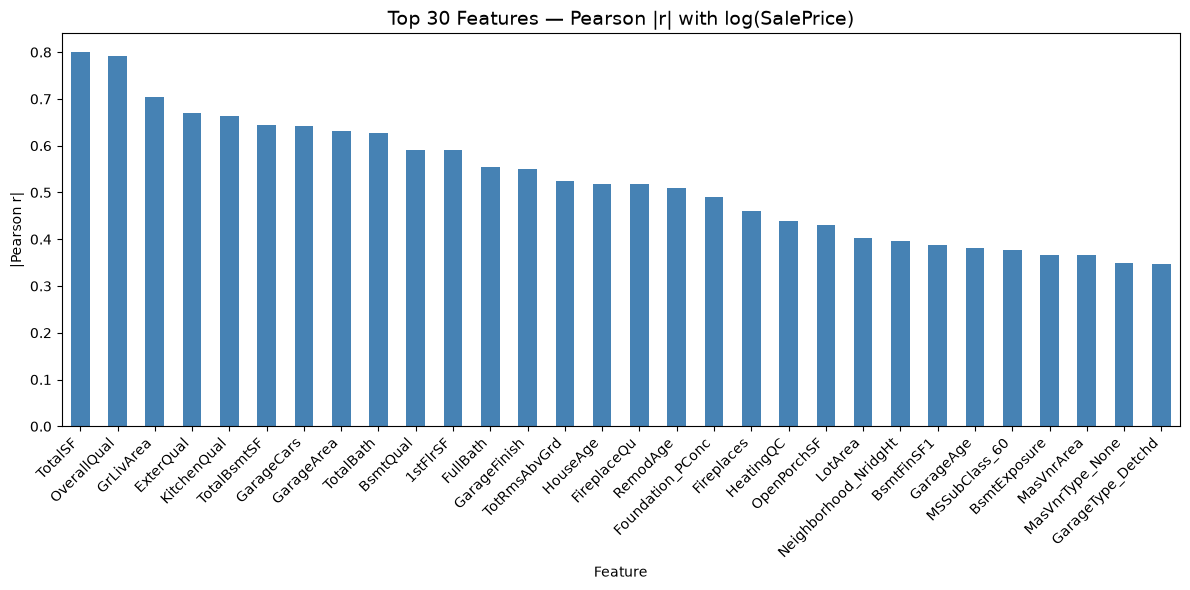

Features with |r| < 0.05 with target: 62


In [3]:
# Pearson Correlation with log(SalePrice)
# Diagnostic: rank features by linear relationship with the target.
# NOTE: Used as a signal only — NOT an automatic deletion rule.
#       Non-linear models (RF, LightGBM) can exploit features with low Pearson r.

pearson_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)

# Visualise top 30
plt.figure(figsize=(12, 6))
pearson_corr.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Features — Pearson |r| with log(SalePrice)', fontsize=14)
plt.ylabel('|Pearson r|')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Flag features with near-zero correlation
weak_corr_features = pearson_corr[pearson_corr < 0.05].index.tolist()
print(f'Features with |r| < 0.05 with target: {len(weak_corr_features)}')

### Block 4 — Filter: Feature-to-Feature High Correlation

In [4]:
# Feature-to-Feature Correlation (|r| >= 0.90)
# When two features are almost identical, keeping both adds noise without new information.
# Decision rule: from each high-corr pair, drop the one with LOWER target correlation.

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
         .query('Correlation >= 0.90')
         .sort_values('Correlation', ascending=False)
         .reset_index(drop=True)
)

print(f'Highly correlated pairs (|r| >= 0.90): {len(high_corr_pairs)}')
display(high_corr_pairs.head(20))

# Drop the weaker feature from each pair
to_drop_corr = []
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row['Feature_1'], row['Feature_2']
    if f1 not in to_drop_corr and f2 not in to_drop_corr:
        drop = f1 if pearson_corr.get(f1, 0) < pearson_corr.get(f2, 0) else f2
        to_drop_corr.append(drop)

print(f'Features flagged for removal (weaker of each pair): {len(to_drop_corr)}')

Highly correlated pairs (|r| >= 0.90): 18


,Feature_1,Feature_2,Correlation
0,RoofMatl_CompShg,RoofMatl_Other,1.000000
1,CentralAir_N,CentralAir_Y,1.000000
2,SaleType_New,SaleCondition_Partial,0.994314
3,MasVnrArea,MasVnrType_None,0.983553
4,MSSubClass_190,BldgType_2fmCon,0.982176
5,MiscVal,MiscFeature_None,0.977147
6,GarageCond,GarageType_None,0.975870
7,Exterior1st_VinylSd,Exterior2nd_VinylSd,0.973984
8,Exterior1st_MetalSd,Exterior2nd_MetalSd,0.972695
9,Exterior1st_CemntBd,Exterior2nd_CmentBd,0.964250


Features flagged for removal (weaker of each pair): 16


### Block 5 — Filter: VIF (Variance Inflation Factor)

In [5]:
# VIF — Variance Inflation Factor
# Measures how much each feature's variance is inflated by multicollinearity.
# Only computed on numerical (non-binary) features.
#
# VIF 1-4  : No issue — keep
# VIF 5-10 : Moderate — monitor
# VIF > 10 : Severe — removal candidate
#
# IMPORTANT: Do NOT remove all high-VIF features. The OLS vs Ridge narrative
# requires OLS to struggle with multicollinearity so Ridge can show its advantage.

num_cols = [col for col in X_train.columns if X_train[col].nunique() > 2]
X_num    = X_train[num_cols].reset_index(drop=True)

# Pre-clean: drop near-constant columns (std < 1e-8) — they cause SVD failure
low_var_mask   = X_num.std() > 1e-8
X_num          = X_num.loc[:, low_var_mask]
num_cols_clean = X_num.columns.tolist()
print(f'Numerical features for VIF: {len(num_cols_clean)}')

# Compute VIF individually with error handling
vif_scores = []
for i, col in enumerate(num_cols_clean):
    try:
        score = variance_inflation_factor(X_num.values, i)
    except Exception:
        score = float('nan')  # Perfect collinearity — treat as severe
    vif_scores.append(score)

vif_data = pd.DataFrame({
    'Feature': num_cols_clean,
    'VIF':     vif_scores
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF Report (Top 20) ===')
display(vif_data.head(20))

# Save
vif_data.to_csv('../data/processed/vif_report.csv', index=False)
print('vif_report.csv saved.')

# Flag severe cases
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
nan_vif_features  = vif_data[vif_data['VIF'].isna()]['Feature'].tolist()
print(f'Features with VIF > 10        : {len(high_vif_features)}')
print(f'Features with uncomputable VIF : {len(nan_vif_features)}')
high_vif_features += nan_vif_features

Numerical features for VIF: 48
=== VIF Report (Top 20) ===


,Feature,VIF
0,TotalBath,4744.822090
1,FullBath,2386.394154
2,BsmtFullBath,2126.522895
3,HalfBath,497.534562
4,TotalSF,113.915246
5,BsmtHalfBath,109.179889
6,GrLivArea,57.736357
7,TotalBsmtSF,37.277607
8,GarageCond,15.740215
9,1stFlrSF,15.482057


vif_report.csv saved.
Features with VIF > 10        : 12
Features with uncomputable VIF : 0


### Block 6 — Build Filter Method Candidate Set

In [6]:
# Filter Method — Final Candidate Set
# Combine all filter flags: weak target correlation + high feature correlation + high VIF

filter_drop = list(set(weak_corr_features + to_drop_corr + high_vif_features))
filter_keep = [col for col in X_train.columns if col not in filter_drop]

X_train_filter = X_train[filter_keep].copy()
X_test_filter  = X_test[filter_keep].copy()

print('=== Filter Method Candidate Set ===')
print(f'Original features : {X_train.shape[1]}')
print(f'Features removed  : {len(filter_drop)}')
print(f'Features kept     : {X_train_filter.shape[1]}')

=== Filter Method Candidate Set ===
Original features : 213
Features removed  : 87
Features kept     : 126


---
## Embedded Methods

Embedded methods perform feature selection during model training.
The model's own learning process determines which features to keep or discard.

- **LassoCV** — L1 penalty forces useless feature coefficients to exactly zero
- **Random Forest Importance** — built-in importance scores from tree splits

### Block 7 — Embedded: LassoCV

Best alpha (regularization strength): 10.000000
Features with non-zero coefficient (kept) : 183
Features zeroed out (removed)             : 30
lasso_coefficients.csv saved.


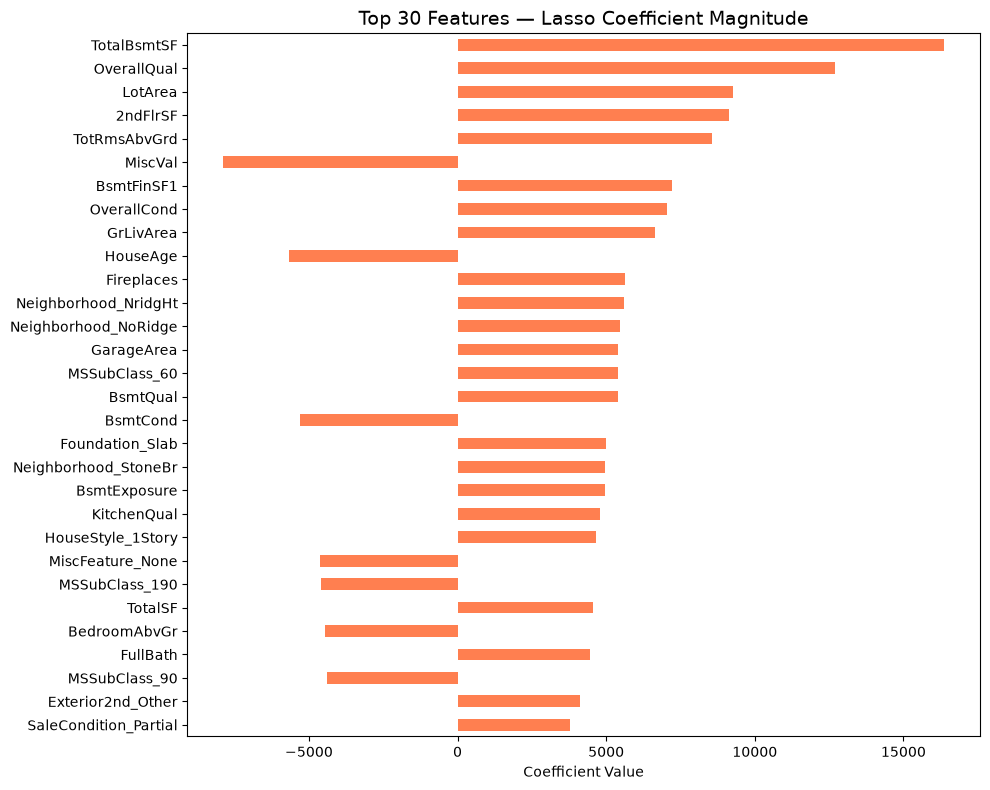

Lasso (Embedded) candidate set: 183 features


In [7]:
# LassoCV — L1 Regularization
# Lasso applies a penalty that drives the coefficients of useless features to exactly 0.
# LassoCV finds the optimal regularization strength (alpha) via cross-validation.

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=5,
    max_iter=10_000,
    random_state=42
)
lasso_cv.fit(X_train, y_train)

print(f'Best alpha (regularization strength): {lasso_cv.alpha_:.6f}')

# Extract coefficients
lasso_coefs    = pd.Series(lasso_cv.coef_, index=X_train.columns)
lasso_selected = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
lasso_zeroed   = lasso_coefs[lasso_coefs == 0]

print(f'Features with non-zero coefficient (kept) : {len(lasso_selected)}')
print(f'Features zeroed out (removed)             : {len(lasso_zeroed)}')

# Save
lasso_coefs.sort_values(key=abs, ascending=False).to_frame('coefficient').to_csv('../data/processed/lasso_coefficients.csv')
print('lasso_coefficients.csv saved.')

# Visualise top 30
plt.figure(figsize=(10, 8))
lasso_selected.head(30).plot(kind='barh', color='coral')
plt.title('Top 30 Features — Lasso Coefficient Magnitude', fontsize=14)
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Build Lasso candidate set
lasso_cols    = lasso_selected.index.tolist()
X_train_lasso = X_train[lasso_cols].copy()
X_test_lasso  = X_test[lasso_cols].copy()

print(f'Lasso (Embedded) candidate set: {X_train_lasso.shape[1]} features')

### Block 8 — Embedded: Random Forest Feature Importance

rf_importance.csv saved.


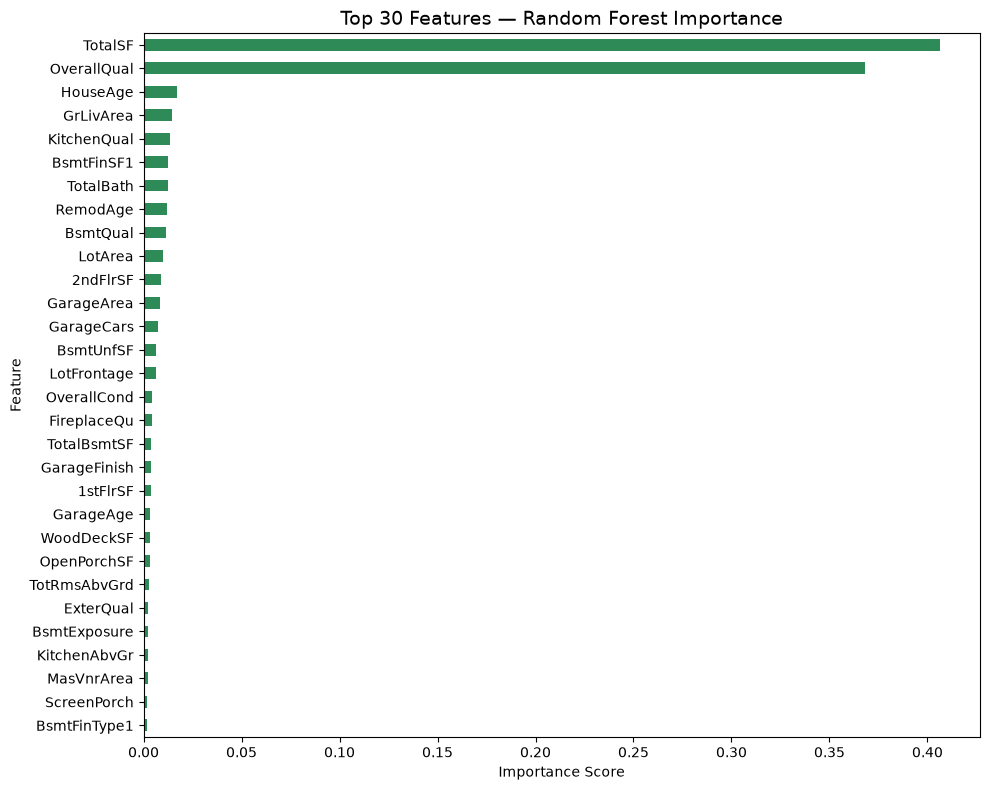

RF Importance (Embedded) candidate set: 150 features


In [8]:
# Random Forest Feature Importance
# RF internally calculates how much each feature reduces prediction error across all trees.
# This captures non-linear relationships that Lasso cannot detect.

rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Save
rf_importance.to_csv('../data/processed/rf_importance.csv', index=False)
print('rf_importance.csv saved.')

# Visualise top 30
plt.figure(figsize=(10, 8))
rf_importance.head(30).set_index('Feature')['Importance'].plot(kind='barh', color='seagreen')
plt.title('Top 30 Features — Random Forest Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Build RF candidate set — top 150 features
rf_cols    = rf_importance.head(150)['Feature'].tolist()
X_train_rf = X_train[rf_cols].copy()
X_test_rf  = X_test[rf_cols].copy()

print(f'RF Importance (Embedded) candidate set: {X_train_rf.shape[1]} features')

---
## Wrapper Methods

Wrapper methods evaluate subsets of features by actually training a model on each subset and measuring CV performance.

- **RFECV** — Recursive Feature Elimination with Cross-Validation. Automatically finds the optimal feature count.

### Block 9 — Wrapper: RFECV

Optimal number of features found by RFECV: 68


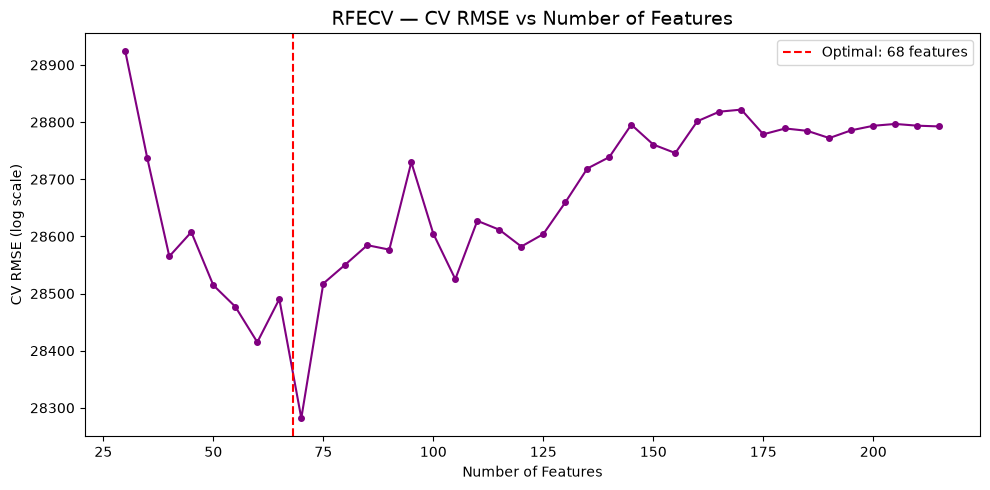

RFECV (Wrapper) candidate set: 68 features


In [9]:
# RFECV — Recursive Feature Elimination with Cross-Validation
# Works by:
#   1. Training a model on all features
#   2. Removing the least important feature(s)
#   3. Retraining on remaining features
#   4. Repeating — CV score tells it when to stop

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=Ridge(alpha=1.0),
    step=5,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=30,
    n_jobs=-1
)
rfecv.fit(X_train, y_train)

print(f'Optimal number of features found by RFECV: {rfecv.n_features_}')

# Plot CV RMSE vs number of features
n_features_range = range(30, 30 + len(rfecv.cv_results_['mean_test_score']) * 5, 5)

plt.figure(figsize=(10, 5))
plt.plot(list(n_features_range), -rfecv.cv_results_['mean_test_score'],
         marker='o', markersize=4, linewidth=1.5, color='purple')
plt.axvline(x=rfecv.n_features_, color='red', linestyle='--',
            label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel('Number of Features')
plt.ylabel('CV RMSE (log scale)')
plt.title('RFECV — CV RMSE vs Number of Features', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Build RFECV candidate set
rfe_cols    = X_train.columns[rfecv.support_].tolist()
X_train_rfe = X_train[rfe_cols].copy()
X_test_rfe  = X_test[rfe_cols].copy()

print(f'RFECV (Wrapper) candidate set: {X_train_rfe.shape[1]} features')

---
## Block 10 — Compare All Candidate Sets (CV RMSE)

All candidate sets are evaluated using the same 5-fold CV on X_train only.
The baseline (all features) is included for reference.

=== Candidate Set Comparison (5-Fold CV RMSE on log SalePrice) ===


,Features,CV RMSE,Std
Wrapper — RFECV,68.0,26088.54051,1373.42462
Embedded — RF Importance,150.0,28016.34859,1559.25842
Embedded — Lasso,183.0,28444.50232,1810.70872
Baseline (All features),213.0,28792.44529,2012.50580
Filter Method,126.0,29341.31004,2217.86338


cv_feature_comparison.csv saved.


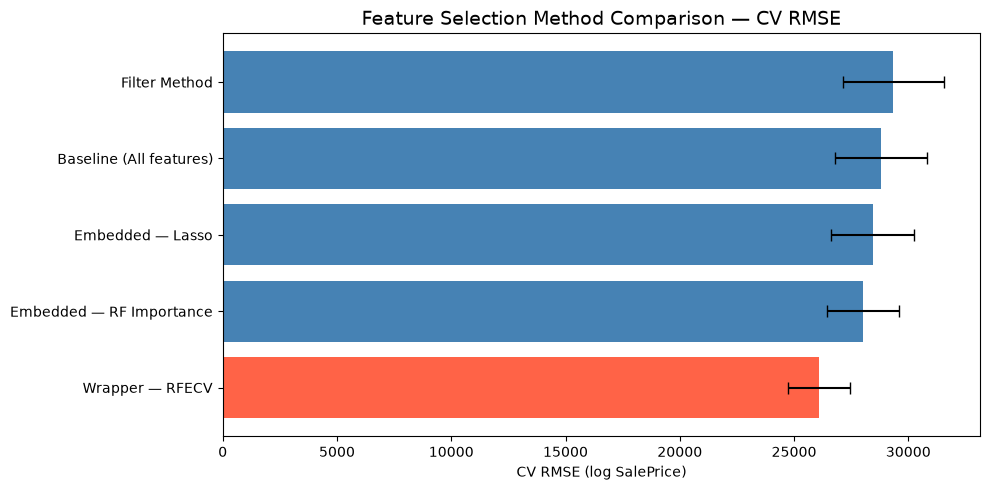

In [10]:
# Compare All Candidate Sets

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

candidate_sets = {
    'Baseline (All features)':    X_train,
    'Filter Method':              X_train_filter,
    'Embedded — Lasso':           X_train_lasso,
    'Embedded — RF Importance':   X_train_rf,
    'Wrapper — RFECV':            X_train_rfe,
}

results = {}
for name, X_candidate in candidate_sets.items():
    scores = cross_val_score(
        Ridge(alpha=1.0),
        X_candidate, y_train,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error'
    )
    results[name] = {
        'Features': X_candidate.shape[1],
        'CV RMSE':  round(-scores.mean(), 5),
        'Std':      round(scores.std(), 5)
    }

comparison_df = pd.DataFrame(results).T.sort_values('CV RMSE')
print('=== Candidate Set Comparison (5-Fold CV RMSE on log SalePrice) ===')
display(comparison_df)

# Save
comparison_df.to_csv('../data/processed/cv_feature_comparison.csv')
print('cv_feature_comparison.csv saved.')

# Visualise
plt.figure(figsize=(10, 5))
colors = ['tomato'] + ['steelblue'] * (len(comparison_df) - 1)
plt.barh(
    comparison_df.index,
    comparison_df['CV RMSE'],
    color=colors,
    xerr=comparison_df['Std'],
    capsize=4
)
plt.xlabel('CV RMSE (log SalePrice)')
plt.title('Feature Selection Method Comparison — CV RMSE', fontsize=14)
plt.tight_layout()
plt.show()

---
## Block 11 — Assign Final Feature Sets to Models

Based on the CV comparison, assign each method's output to the appropriate model(s).

| Dataset | Feature Source | Used By |
|---|---|---|
| `X_strict` | Lasso (non-zero) + VIF-cleaned | OLS |
| `X_mid` | RFECV optimal set | Ridge, SVR-RBF |
| `X_full` | RF Importance top 150 | Random Forest, LightGBM, K-Means |

In [11]:
# X_strict — OLS (Lasso + VIF cleaned)
# OLS is most sensitive to multicollinearity and noise.
# Give it only the Lasso-confirmed features with VIF issues removed.

strict_cols    = [col for col in lasso_cols if col not in high_vif_features]
X_train_strict = X_train[strict_cols].copy()
X_test_strict  = X_test[strict_cols].copy()

print(f'X_strict : {X_train_strict.shape[1]} features  (OLS)')

# X_mid — Ridge, SVR (RFECV optimal)
# RFECV found the CV-optimal feature count. Ridge and SVR get the validated middle ground.

mid_cols    = rfe_cols
X_train_mid = X_train[mid_cols].copy()
X_test_mid  = X_test[mid_cols].copy()

print(f'X_mid    : {X_train_mid.shape[1]} features  (Ridge, SVR-RBF)')

# X_full — RF, LightGBM, K-Means (RF Importance top 150)
# Tree models handle noise internally — give them the broadest set.
# K-Means reuses this set: features that define price also define market tiers.

full_cols    = rf_cols
X_train_full = X_train[full_cols].copy()
X_test_full  = X_test[full_cols].copy()

print(f'X_full   : {X_train_full.shape[1]} features  (Random Forest, LightGBM, K-Means)')

X_strict : 172 features  (OLS)
X_mid    : 68 features  (Ridge, SVR-RBF)
X_full   : 150 features  (Random Forest, LightGBM, K-Means)


---
## Block 12 — Save All Output Datasets

In [12]:
# Save all feature-selected datasets
# Test sets receive the same column selection applied mechanically.
# No statistics are ever computed from the test set.

X_train_strict.to_csv('../data/final_for_modeling/X_train_strict.csv', index=False)
X_test_strict.to_csv('../data/final_for_modeling/X_test_strict.csv',   index=False)

X_train_mid.to_csv('../data/final_for_modeling/X_train_mid.csv', index=False)
X_test_mid.to_csv('../data/final_for_modeling/X_test_mid.csv',   index=False)

X_train_full.to_csv('../data/final_for_modeling/X_train_full.csv', index=False)
X_test_full.to_csv('../data/final_for_modeling/X_test_full.csv',   index=False)

print('=== All Datasets Saved ===')
print(f'X_train_strict : {X_train_strict.shape}  |  X_test_strict : {X_test_strict.shape}')
print(f'X_train_mid    : {X_train_mid.shape}  |  X_test_mid    : {X_test_mid.shape}')
print(f'X_train_full   : {X_train_full.shape}  |  X_test_full   : {X_test_full.shape}')

print('\n=== Final Feature Selection Summary ===')
summary = pd.DataFrame({
    'Dataset':  ['X_strict', 'X_mid', 'X_full'],
    'Method':   ['Embedded (Lasso) + Filter (VIF)', 'Wrapper (RFECV)', 'Embedded (RF Importance)'],
    'Features': [X_train_strict.shape[1], X_train_mid.shape[1], X_train_full.shape[1]],
    'Used By':  ['OLS', 'Ridge, SVR-RBF', 'Random Forest, LightGBM, K-Means']
})
display(summary)

=== All Datasets Saved ===
X_train_strict : (1166, 172)  |  X_test_strict : (292, 172)
X_train_mid    : (1166, 68)  |  X_test_mid    : (292, 68)
X_train_full   : (1166, 150)  |  X_test_full   : (292, 150)

=== Final Feature Selection Summary ===


,Dataset,Method,Features,Used By
0,X_strict,Embedded (Lasso) + Filter (VIF),172,OLS
1,X_mid,Wrapper (RFECV),68,"Ridge, SVR-RBF"
2,X_full,Embedded (RF Importance),150,"Random Forest, LightGBM, K-Means"
